# EDA: Scatterplots for Every Pair of Variables

A scatterplot for every pair of variables (features and target) -- tight clustering along a line/curve means the two are strongly related, a shapeless cloud means they're not.

Categorical columns (Weather, Traffic_Level, Time_of_Day, Vehicle_Type) don't have a numeric scale, so they're plotted at one position per category with a little random jitter added -- this just spreads overlapping points into a visible cloud at each category instead of a single dot, it doesn't change what the data says.

Run this notebook via `kedro jupyter notebook` (or `kedro jupyter lab`) from the project root so the `catalog` variable is available.

In [22]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [23]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from model_pipeline.pipelines.model_pipeline.nodes import CATEGORICAL_COLS, NUMERICAL_COLS

In [24]:
parameters = catalog.load("params:model_options")
TARGET = parameters["target_column"]

data = catalog.load("int_food_delivery")
data = data[NUMERICAL_COLS + CATEGORICAL_COLS + [TARGET]]

[08/17/26 08:38:24] INFO     Loading data from params:model_options (MemoryDataset)...         ]8;id=4057271;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=4057272;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from int_food_delivery (CSVDataset)...               ]8;id=4057277;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=4057278;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

## Numerical Feature Summary

Mean, median, and standard deviation for each numerical feature, plus a `mean ± 3*SD` bound -- values outside that range are far enough from the center to be worth a second look as potential outliers (the "3-sigma rule").

In [25]:
summary = data[NUMERICAL_COLS + [TARGET]].agg(["mean", "median", "std"]).T
summary.columns = ["Mean", "Median", "Std Dev"]
summary["Lower Bound (mean - 3*SD)"] = summary["Mean"] - 3 * summary["Std Dev"]
summary["Upper Bound (mean + 3*SD)"] = summary["Mean"] + 3 * summary["Std Dev"]
summary.index.name = "Feature"

summary.reset_index().round(2)

,Feature,Mean,Median,Std Dev,Lower Bound (mean - 3*SD),Upper Bound (mean + 3*SD)
0,Distance_km,10.06,10.19,5.70,-7.03,27.15
1,Preparation_Time_min,16.98,17.00,7.20,-4.63,38.60
2,Courier_Experience_yrs,4.58,5.00,2.91,-4.16,13.32
3,Delivery_Time_min,56.73,55.50,22.07,-9.48,122.94


## Feature Correlation Matrix

How strongly each pair of *features* moves together (the target is excluded here -- see the sections below for feature-vs-target). Numbers near 0 mean the two features carry mostly independent information; numbers near 1 (or -1) mean they're saying almost the same thing, which is worth knowing since redundant features can often be dropped or combined.

The features mix numeric and categorical columns, so three formulas feed into one matrix:
- Two numeric columns: standard correlation (can be negative or positive).
- Two categorical columns: Cramer's V (always 0 to 1).
- One numeric, one categorical: correlation ratio (always 0 to 1) -- how much of the numeric column's spread lines up with the categorical column's groups.

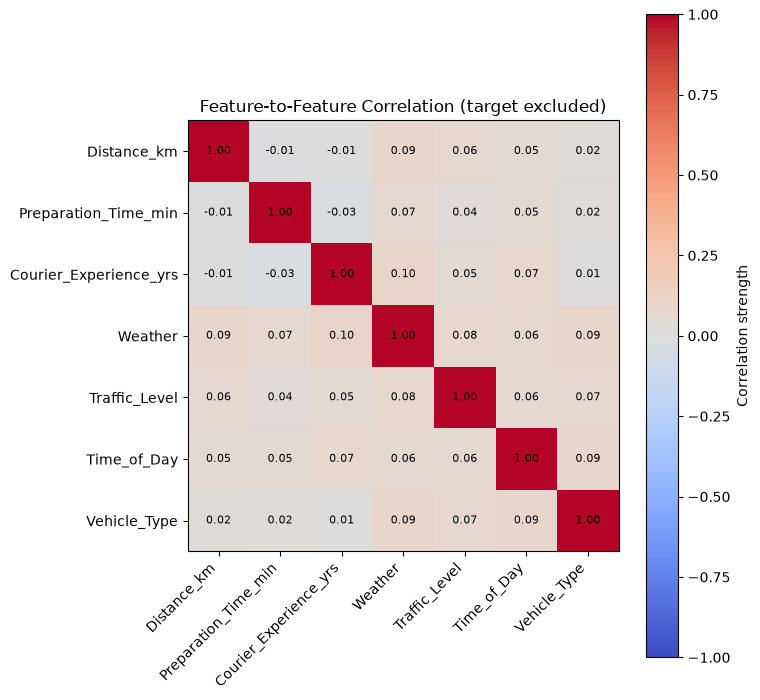

In [26]:
from scipy.stats import chi2_contingency


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Association between two categorical columns, from 0 (unrelated) to 1 (perfectly related)."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return float(np.sqrt((chi2 / n) / min(k - 1, r - 1)))


def correlation_ratio(categories: pd.Series, values: pd.Series) -> float:
    """Association between a categorical column and a numeric column, from 0 to 1:
    how much of the numeric column's spread lines up with the categorical
    column's groups.
    """
    paired = pd.DataFrame({"category": categories, "value": values}).dropna()
    overall_mean = paired["value"].mean()
    group_stats = paired.groupby("category")["value"].agg(["mean", "count"])

    between_group_ss = (group_stats["count"] * (group_stats["mean"] - overall_mean) ** 2).sum()
    total_ss = ((paired["value"] - overall_mean) ** 2).sum()

    if total_ss == 0:
        return 0.0
    return float(np.sqrt(between_group_ss / total_ss))


def feature_correlation_matrix(
    df: pd.DataFrame, numerical_cols: list, categorical_cols: list
) -> pd.DataFrame:
    """Feature-to-feature correlation matrix (target excluded), using the
    matching measure for each pair of column types.
    """
    all_cols = numerical_cols + categorical_cols
    matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

    for col_a in all_cols:
        for col_b in all_cols:
            if col_a == col_b:
                matrix.loc[col_a, col_b] = 1.0
            elif col_a in numerical_cols and col_b in numerical_cols:
                matrix.loc[col_a, col_b] = df[col_a].corr(df[col_b])
            elif col_a in categorical_cols and col_b in categorical_cols:
                matrix.loc[col_a, col_b] = cramers_v(df[col_a], df[col_b])
            elif col_a in numerical_cols and col_b in categorical_cols:
                matrix.loc[col_a, col_b] = correlation_ratio(df[col_b], df[col_a])
            else:
                matrix.loc[col_a, col_b] = correlation_ratio(df[col_a], df[col_b])

    return matrix


correlation_matrix = feature_correlation_matrix(data, NUMERICAL_COLS, CATEGORICAL_COLS)

fig, ax = plt.subplots(
    figsize=(0.8 * len(correlation_matrix.columns) + 2, 0.8 * len(correlation_matrix.columns) + 2)
)
im = ax.imshow(correlation_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j, i, f"{correlation_matrix.values[i, j]:.2f}",
            ha="center", va="center", fontsize=8,
        )

fig.colorbar(im, ax=ax, label="Correlation strength")
ax.set_title("Feature-to-Feature Correlation (target excluded)")
fig.tight_layout()
plt.show()

In [27]:
def _plot_values(series: pd.Series):
    """Numeric columns are returned as-is. Categorical columns are converted
    to one integer position per category, with small random jitter so points
    sharing a category don't all land exactly on top of each other.
    """
    if series.name in CATEGORICAL_COLS:
        codes, categories = pd.factorize(series)
        jitter = np.random.uniform(-0.15, 0.15, size=len(codes))
        return codes + jitter, list(range(len(categories))), list(categories)
    return series.to_numpy(), None, None


def plot_pair(ax, df, col_x, col_y):
    x_vals, x_ticks, x_labels = _plot_values(df[col_x])
    y_vals, y_ticks, y_labels = _plot_values(df[col_y])

    ax.scatter(x_vals, y_vals, alpha=0.4, s=10)

    if x_ticks is not None:
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=7)
    if y_ticks is not None:
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_labels, fontsize=7)

    ax.set_xlabel(col_x, fontsize=8)
    ax.set_ylabel(col_y, fontsize=8)


def plot_all_pairs(df, pairs, title, n_cols=4):
    n_rows = -(-len(pairs) // n_cols)  # ceil division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, (col_x, col_y) in zip(axes, pairs):
        plot_pair(ax, df, col_x, col_y)

    for ax in axes[len(pairs):]:
        ax.axis("off")

    fig.suptitle(title, y=1.0)
    fig.tight_layout()
    plt.show()

## Each Feature vs the Target

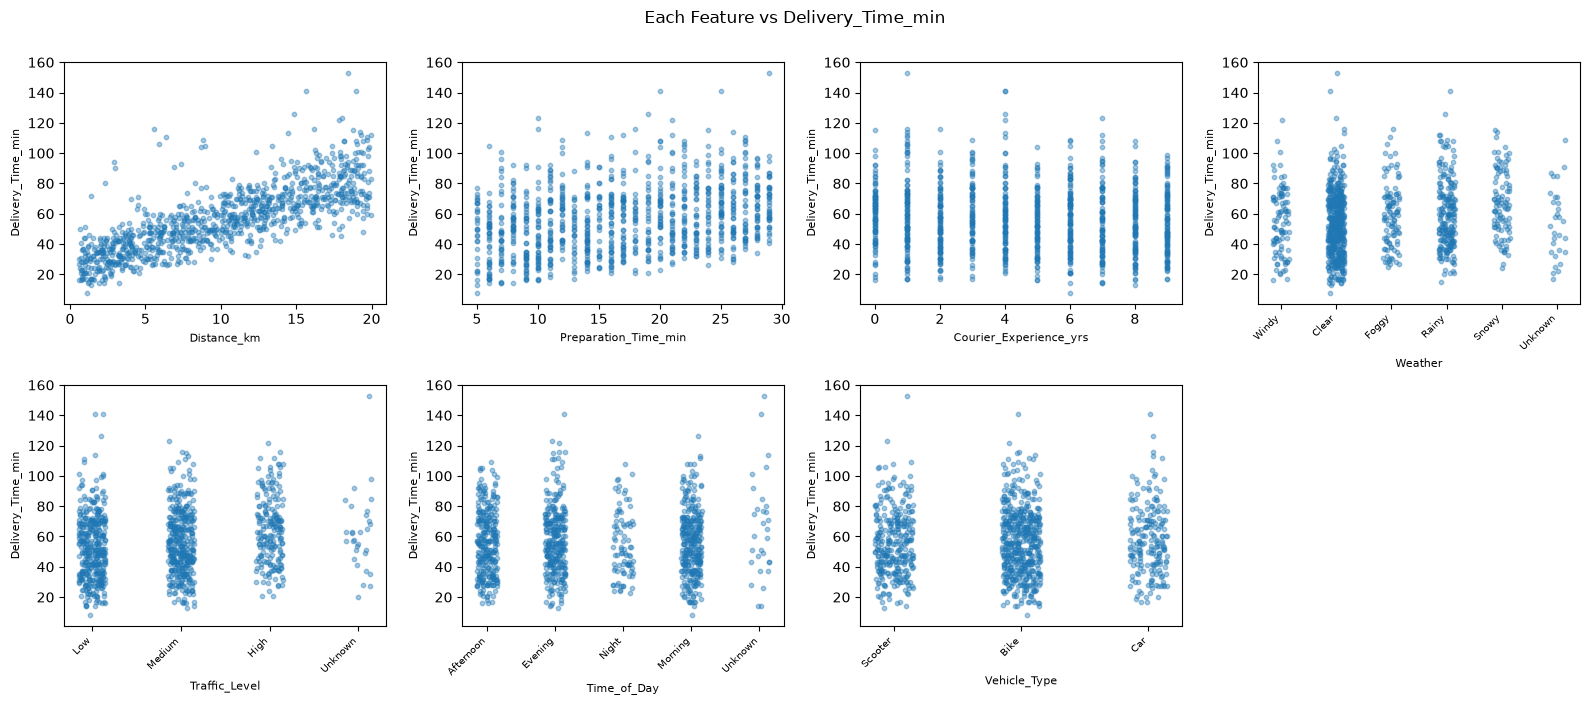

In [28]:
feature_cols = NUMERICAL_COLS + CATEGORICAL_COLS
target_pairs = [(col, TARGET) for col in feature_cols]

plot_all_pairs(data, target_pairs, f"Each Feature vs {TARGET}")

## Every Feature vs Every Other Feature

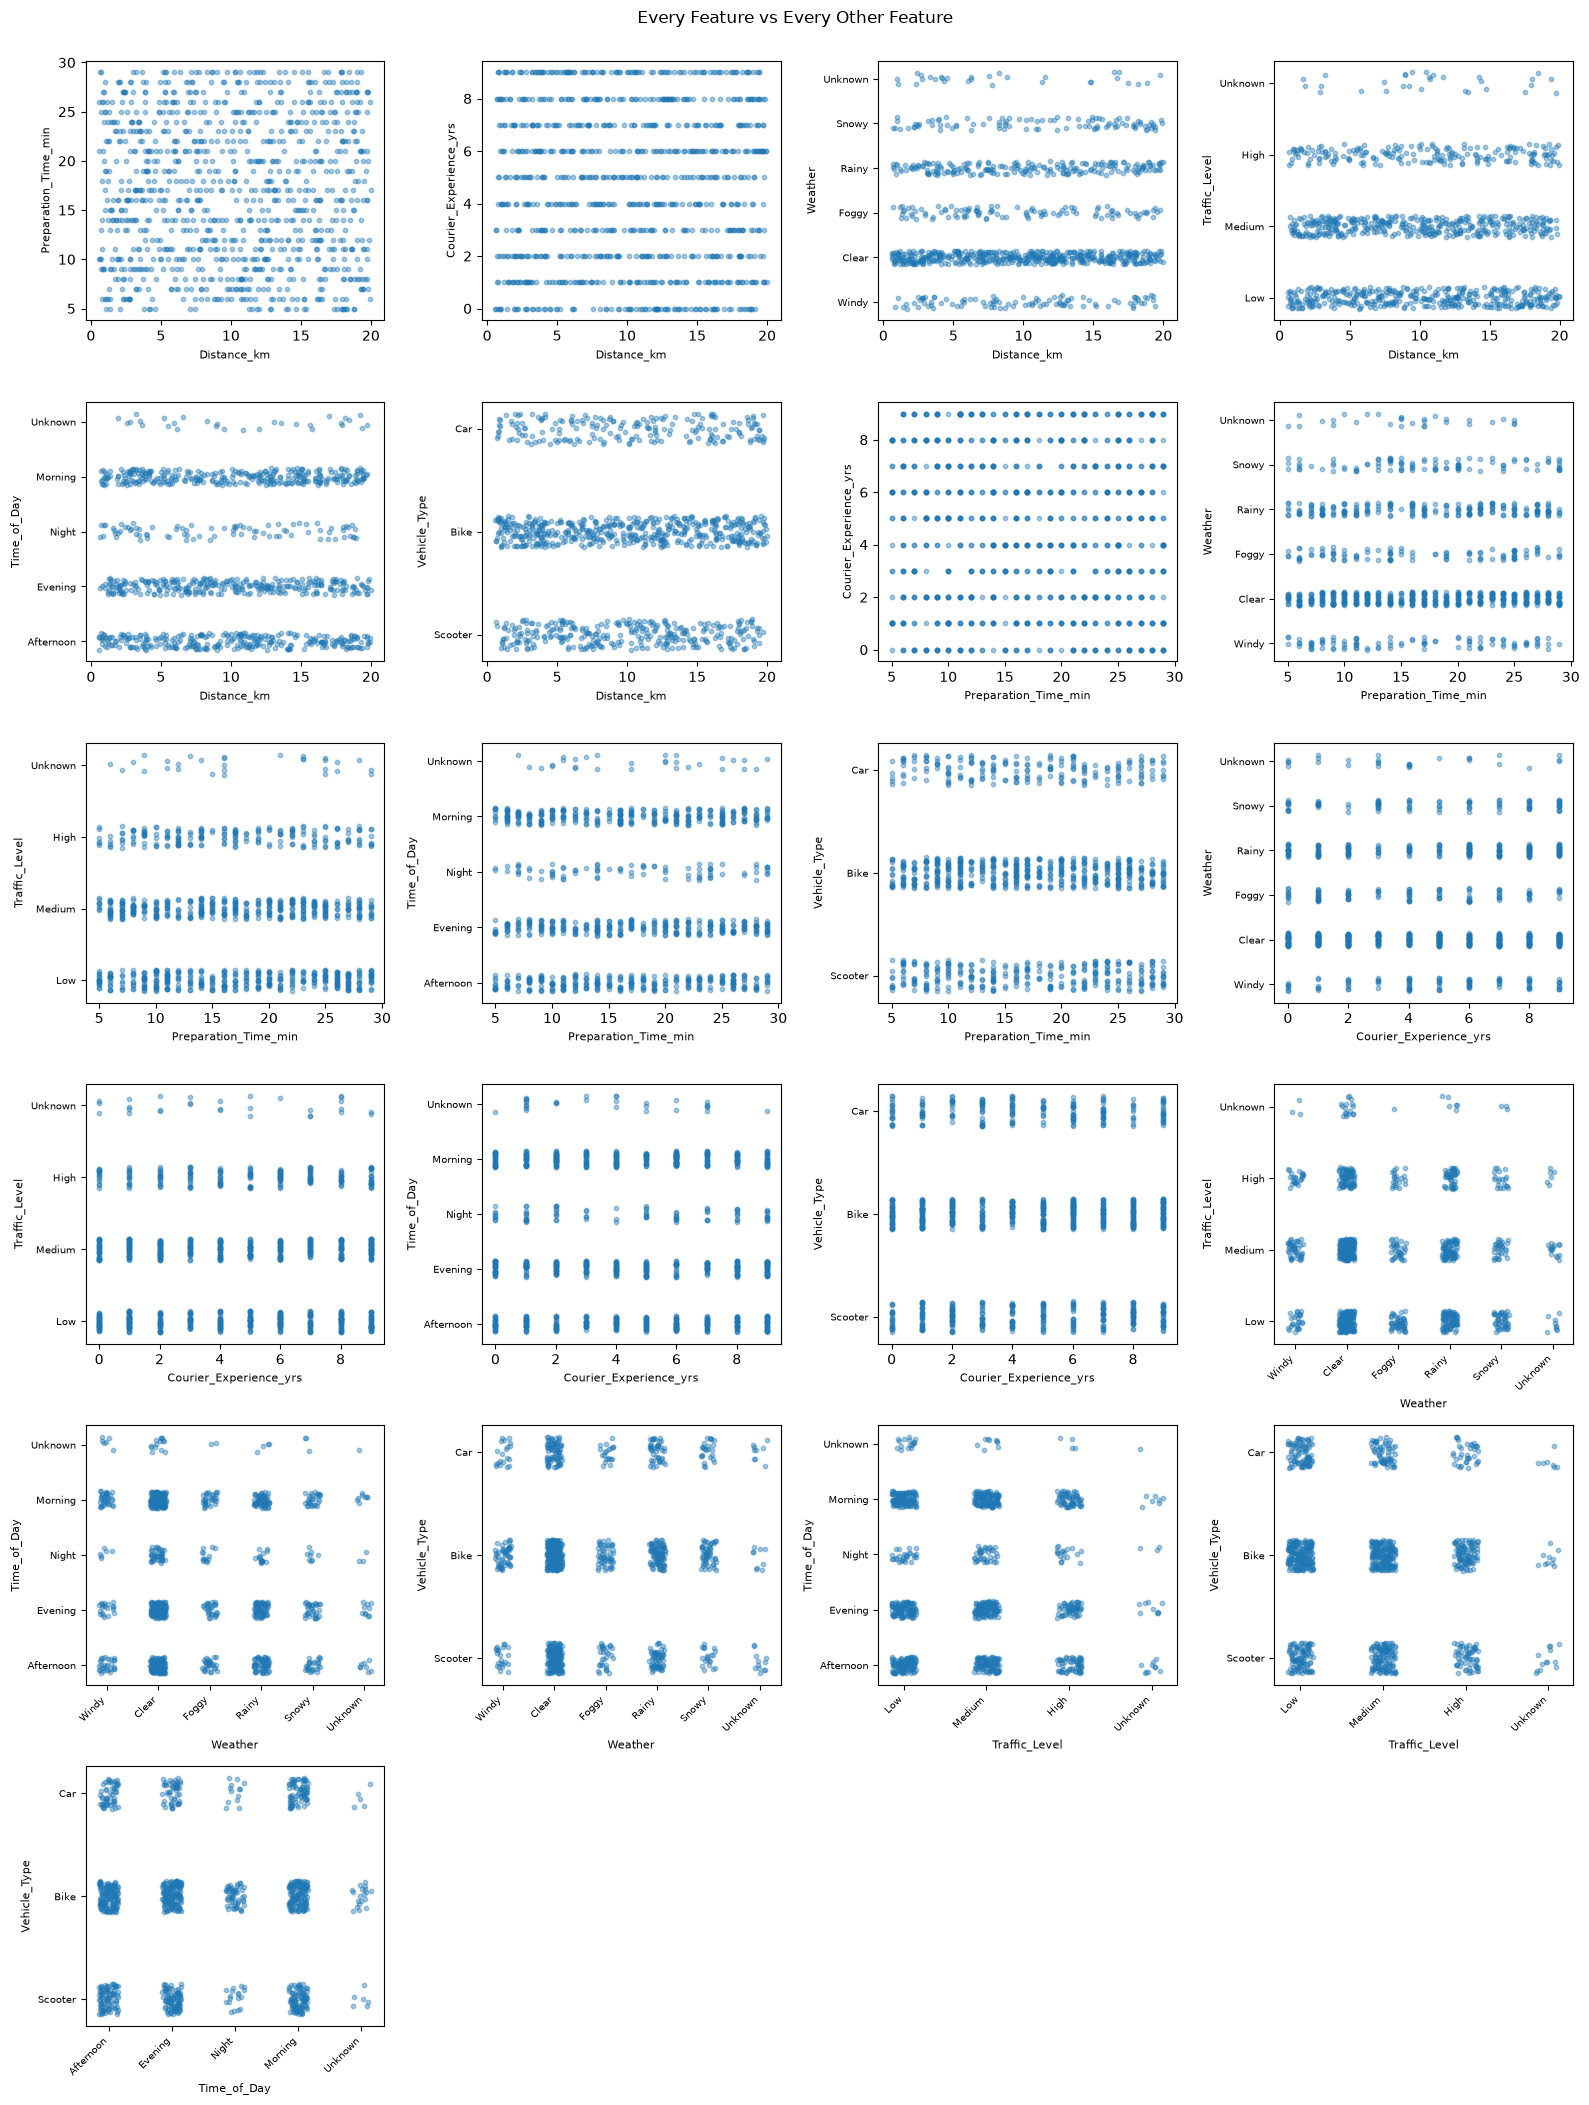

In [29]:
feature_pairs = list(itertools.combinations(feature_cols, 2))

plot_all_pairs(data, feature_pairs, "Every Feature vs Every Other Feature")